In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime as dt
df = pd.read_csv('/kaggle/input/datasets/zunairahassann/unemployment/Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [25]:

print(f"Your dataset has {len(df.columns)} columns.")
if len(df.columns) == 9:
    df.columns = ["States", "Date", "Frequency", "Estimated Unemployment Rate (%)", 
                  "Estimated Employed", "Estimated Labour Participation Rate (%)", 
                  "Region", "longitude", "latitude"]
else:
    df.columns = ["States", "Date", "Frequency", "Estimated Unemployment Rate (%)", 
                  "Estimated Employed", "Estimated Labour Participation Rate (%)", 
                  "Region"]

df['States'] = df['States'].str.strip()
if 'Region' in df.columns:
    df['Region'] = df['Region'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month_name()

df.head()

Your dataset has 7 columns.


,States,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


Data cleaning and pre-processing

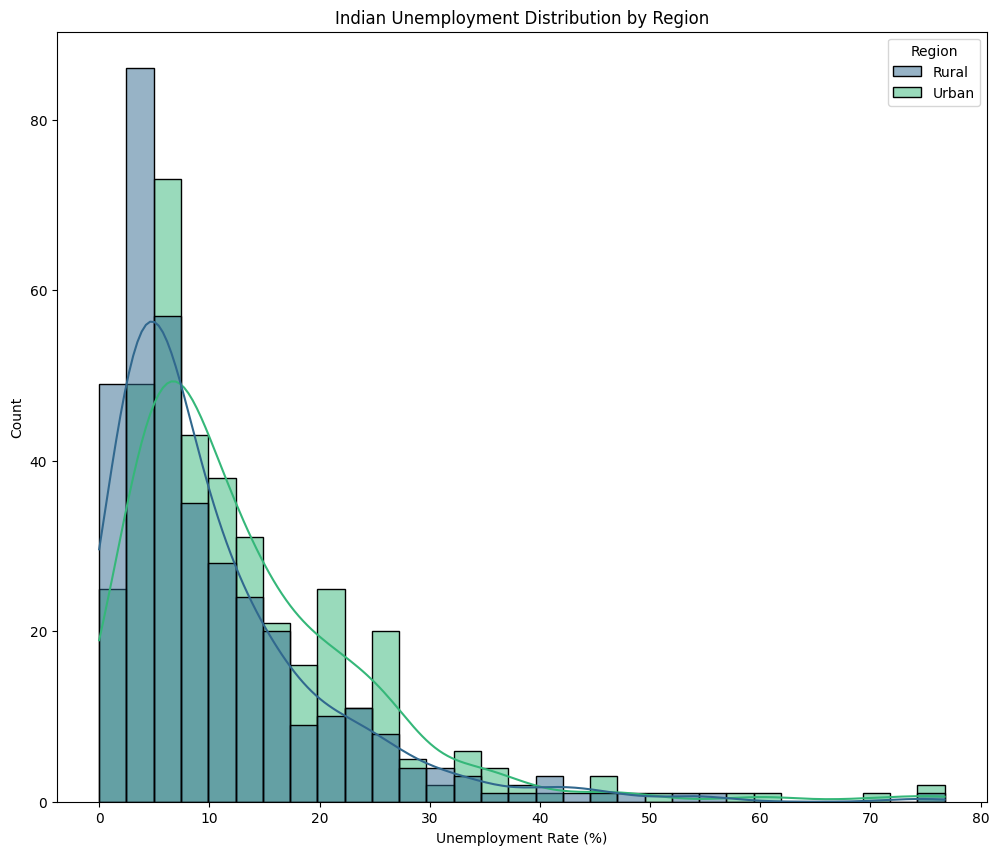

In [26]:
plt.figure(figsize=(12, 10))
plt.title("Indian Unemployment Distribution by Region")
sns.histplot(x="Estimated Unemployment Rate (%)", hue="Region", data=df, kde=True, palette="viridis")
plt.xlabel("Unemployment Rate (%)")
plt.show()

In [27]:

top_unemployment = sunburst_df.sort_values(by='Estimated Unemployment Rate (%)', ascending=False).head(10)
print("Top 10 States with Highest Average Unemployment Rate:")
print(top_unemployment[['States', 'Estimated Unemployment Rate (%)']])

Top 10 States with Highest Average Unemployment Rate:
              States  Estimated Unemployment Rate (%)
51           Tripura                        29.534286
35           Haryana                        27.553571
23           Tripura                        27.166429
38         Jharkhand                        25.948571
7            Haryana                        25.012857
36  Himachal Pradesh                        21.576429
29             Bihar                        21.066429
32             Delhi                        17.732143
37   Jammu & Kashmir                        17.549000
47         Rajasthan                        17.189286


In [28]:

sunburst_df = df.groupby(['Region', 'States'])['Estimated Unemployment Rate (%)'].mean().reset_index()

fig = px.sunburst(
    sunburst_df, 
    path=['Region', 'States'], 
    values='Estimated Unemployment Rate (%)',
    color='Estimated Unemployment Rate (%)',
    color_continuous_scale='RdYlGn_r', # Red for high unemployment, Green for low
    title="Average Unemployment Rate by Region and State",
    height=700,
    template='plotly_dark'
)

fig.update_traces(textinfo="label+percent entry")
fig.show()

In [29]:
# Statistical summary of unemployment by Region
stats = df.groupby("Region")["Estimated Unemployment Rate (%)"].agg(["mean", "std", "min", "max"])
stats.sort_values(by='mean', ascending=False)

,mean,std,min,max
Region,,,,
Urban,13.166614,11.165444,0.0,76.74
Rural,10.324791,10.038895,0.0,74.51


In [30]:

df_grouped = df.groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().reset_index()

fig = px.line(df_grouped, 
              x='Date', 
              y='Estimated Unemployment Rate (%)', 
              color='Region',
              markers=True,
              title='Average Unemployment Rate Trend by Region',
              template='plotly_dark',
              line_shape='linear')

fig.add_vrect(x0="2020-03-25", x1="2020-05-31", 
              fillcolor="red", opacity=0.1, line_width=0,
              annotation_text="Strict Lockdown Period", annotation_position="top left")

fig.show()

In [31]:

lockdown = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-07-31')]

pre_lockdown = df[(df['Date'] < '2020-04-01')]

res_lockdown = lockdown.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
res_pre_lockdown = pre_lockdown.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

lockdown_impact = pd.DataFrame({
    'Pre-Lockdown Avg (%)': res_pre_lockdown,
    'Lockdown Avg (%)': res_lockdown,
    'Increase (%)': res_lockdown - res_pre_lockdown
})

lockdown_impact.sort_values(by='Increase (%)', ascending=False)

,Pre-Lockdown Avg (%),Lockdown Avg (%),Increase (%)
Region,,,
Urban,10.909507,22.077792,11.168286
Rural,8.229049,18.260667,10.031617


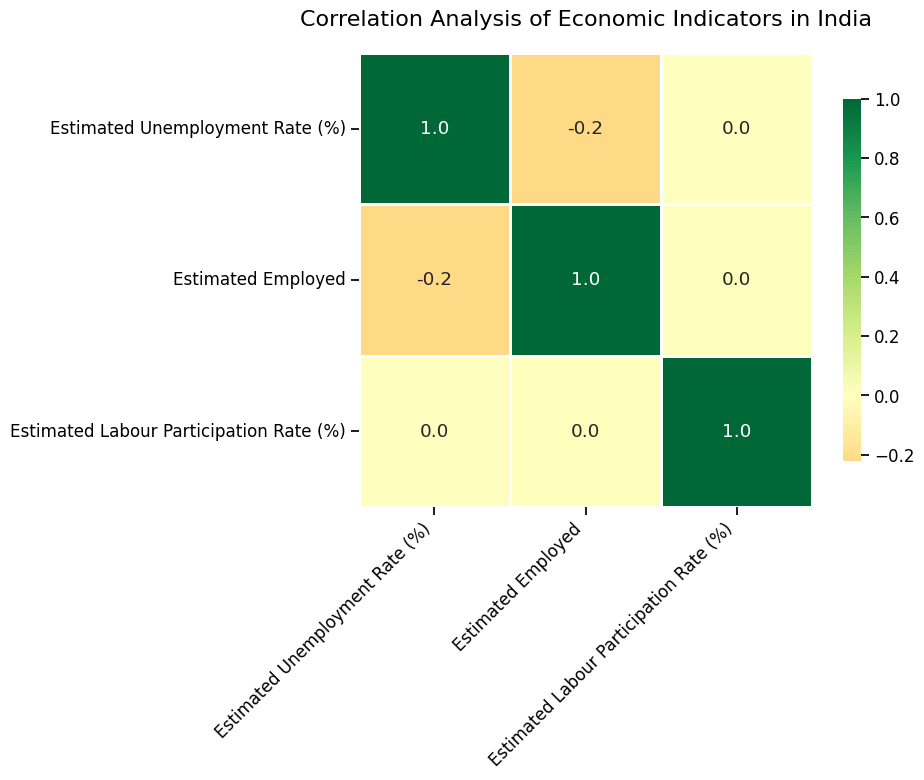

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
numeric_data = df[['Estimated Unemployment Rate (%)', 
                  'Estimated Employed', 
                  'Estimated Labour Participation Rate (%)']]
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.set_context("notebook", font_scale=1.1)
sns.heatmap(
    correlation_matrix, 
    annot=True,               
    fmt=".1f",                 
    cmap="RdYlGn",           
    center=0,                 
    linewidths=2,            
    cbar_kws={'shrink': 0.8},  
    square=True               
)
plt.title("Correlation Analysis of Economic Indicators in India", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)           
plt.tight_layout() 
plt.show()

In [32]:

timeline_comparison = df.groupby(['Date', 'Frequency'])['Estimated Unemployment Rate (%)'].mean().reset_index()

fig = px.area(timeline_comparison, 
              x='Date', 
              y='Estimated Unemployment Rate (%)', 
              color='Frequency',
              title='Unemployment Trend: Urban vs Rural (Jan-Oct 2020)',
              template='plotly_dark',
              line_shape='spline') # Makes the lines smooth

fig.show()

In [33]:

national_avg = df['Estimated Unemployment Rate (%)'].mean()
high_unemployment_states = df[df['Estimated Unemployment Rate (%)'] > national_avg]
high_unemployment_states['States'].value_counts().head(10)

States
Haryana             28
Tripura             28
Delhi               24
Himachal Pradesh    22
Bihar               21
Rajasthan           20
Jharkhand           19
Jammu & Kashmir     18
Punjab              13
Uttar Pradesh       12
Name: count, dtype: int64

In [34]:

df.columns = [c.strip() for c in df.columns]
target_col = 'Estimated Unemployment Rate (%)'
region_col = 'Region'
area_col = 'Frequency' if 'Frequency' in df.columns else None
if area_col:
    df[area_col] = df[area_col].str.strip()
if area_col and target_col in df.columns:
    urban_rural_df = df.groupby([region_col, area_col])[target_col].mean().reset_index()
    
    fig = px.bar(urban_rural_df, 
                 x=region_col, 
                 y=target_col, 
                 color=area_col, 
                 barmode='group',
                 title='Comparison of Urban vs Rural Unemployment Rate by Region',
                 template='plotly_dark',
                 labels={target_col: 'Avg Unemployment Rate (%)'},
                 color_discrete_map={'Urban': '#636EFA', 'Rural': '#00CC96'})
    fig.show()
else:
    print(f"Columns found in your data: {list(df.columns)}")
    print("Error: Required columns for comparison are missing.")

In [35]:

df.to_csv('Cleaned_Unemployment_Data.csv', index=False)
print("Project Analysis Complete. Cleaned data saved!")

Project Analysis Complete. Cleaned data saved!


Conclusion:
The analysis reveals that the Covid-19 lockdown (April–May 2020) caused an unprecedented surge in unemployment, with some states spiking from 5% to over 70%.

Key Insights:
Urban vs. Rural: Urban areas suffered significantly more than rural areas, as city-based sectors (retail, hospitality) were paralyzed while agriculture remained an "essential service."

Regional Impact: States like Haryana and Tripura faced the most prolonged economic stress, indicating that recovery was not uniform across the country.

Policy Takeaway: Future social policies must prioritize urban safety nets and digital job infrastructure to protect high-mobility workers during sudden economic shocks